In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

In [2]:
import os
import zipfile

# Paths
url = "https://files.ffiec.cfpb.gov/dynamic-data/2024/2024_lar.zip"
zip_path = "data/2024_lar.zip" # Corrected to be the actual zip file path
data = "data/2024_lar.txt"    # Corrected to be the actual extracted data file path

# Create folder
os.makedirs("data", exist_ok=True)

# Download if needed
if not os.path.exists(zip_path):
    print("Downloading dataset...")
    !wget -O {zip_path} {url}
    print("Download complete.")
else:
    print("Zip already exists.")

# Unzip if needed
if not os.path.exists(data):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data/")
    print("Extraction complete.")
else:
    print("Text file already exists.")

# Verify
print("Files in data folder:", os.listdir("data"))

--2026-04-29 11:37:49--  https://files.ffiec.cfpb.gov/dynamic-data/2024/2024_lar.zip
Resolving files.ffiec.cfpb.gov (files.ffiec.cfpb.gov)... 23.7.139.119, 2600:1406:5e00:787::31d7, 2600:1406:5e00:7a2::31d7
Connecting to files.ffiec.cfpb.gov (files.ffiec.cfpb.gov)|23.7.139.119|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 665486146 (635M) [application/octet-stream]
Saving to: â€˜data/2024_lar.zipâ€™

data/2024_lar.zip   100%[===================>] 634.66M  21.5MB/s    in 32s     

2026-04-29 11:38:22 (20.0 MB/s) - â€˜data/2024_lar.zipâ€™ saved [665486146/665486146]

Download complete.
Extracting dataset...
Extraction complete.
Files in data folder: ['2024_lar.zip', '2024_lar.txt']


In [3]:
print(os.listdir("data"))

['2024_lar.zip', '2024_lar.txt']


In [4]:
import pandas as pd

file_path = "data/2024_lar.txt" # Define file_path
df = pd.read_csv(
    file_path,
    sep="|",
    low_memory=False)

print("Shape:", df.shape)
df.head(10)

Shape: (12259156, 99)


,activity_year,lei,derived_msa_md,state_code,county_code,census_tract,conforming_loan_limit,derived_loan_product_type,derived_dwelling_category,derived_ethnicity,...,denial_reason_2,denial_reason_3,denial_reason_4,tract_population,tract_minority_population_percent,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,tract_owner_occupied_units,tract_one_to_four_family_homes,tract_median_age_of_housing_units
0,2024,549300HW662MN1WU8550,35614,NY,36005.0,36005029700,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4005,41.65,101900,150.0,959,161,64
1,2024,549300HW662MN1WU8550,47664,MI,26125.0,26125145600,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4629,18.06,109700,112.0,1519,1713,32
2,2024,549300HW662MN1WU8550,38060,AZ,4013.0,04013815502,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2640,37.92,101300,123.0,223,465,14
3,2024,549300HW662MN1WU8550,38900,WA,53011.0,53011041337,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Joint,...,NaN,NaN,NaN,3157,28.38,116900,78.0,574,783,36
4,2024,549300HW662MN1WU8550,33460,WI,55093.0,55093960200,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,6174,7.29,123700,88.0,1713,2141,35
5,2024,549300HW662MN1WU8550,38300,PA,42007.0,42007601000,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,3768,10.40,99100,114.0,1045,1375,66
6,2024,549300HW662MN1WU8550,37860,FL,12033.0,12033002500,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,2939,8.74,92200,215.0,1321,1482,34
7,2024,549300HW662MN1WU8550,41740,CA,6073.0,06073017104,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Ethnicity Not Available,...,NaN,NaN,NaN,4014,24.94,119500,126.0,1114,1331,42
8,2024,549300HW662MN1WU8550,37964,PA,42045.0,42045409100,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Not Hispanic or Latino,...,NaN,NaN,NaN,4198,8.27,84300,177.0,1282,1438,0
9,2024,549300HW662MN1WU8550,41700,TX,48187.0,48187210713,C,Conventional:First Lien,Single Family (1-4 Units):Site-Built,Hispanic or Latino,...,NaN,NaN,NaN,9253,59.02,89300,129.0,2280,2865,10


### Create Label: Target Variable Creation

Based on the project goal, we will create a binary target variable from the `action_taken` column. The rules are as follows:
- `action_taken` values 1 (Loan originated) and 2 (Application approved but not accepted) will be coded as **1**.
- `action_taken` value 3 (Application denied) will be coded as **0**.
- Records with other `action_taken` values will be filtered out.

In [5]:
print("=== Target Variable Definition ===")
print("Label: action_taken values 1 & 2 â†’ 1 (Approved)")
print("       action_taken value 3 â†’ 0 (Denied)\n")

# Map action_taken values 1 and 2 to 1 (Approved), and 3 to 0 (Denied)
df['action_taken'] = df['action_taken'].map({1: 1, 2: 1, 3: 0})

# Filter out records where action_taken was not 1, 2, or 3 (resulting in NaN in 'action_taken')
df.dropna(subset=['action_taken'], inplace=True)

# Convert action_taken to integer type as it's a binary variable
df['action_taken'] = df['action_taken'].astype(int)

print("=== Dataset Summary ===")
print(f"Total records used: {len(df):,}\n")

counts = df['action_taken'].value_counts()
props = df['action_taken'].value_counts(normalize=True)

print("=== Class Distribution ===")
print(f"Approved (1): {counts[1]:,} ({props[1]*100:.2f}%)")
print(f"Denied   (0): {counts[0]:,} ({props[0]*100:.2f}%)")

=== Target Variable Definition ===
Label: action_taken values 1 & 2 â†’ 1 (Approved)
       action_taken value 3 â†’ 0 (Denied)

=== Dataset Summary ===
Total records used: 8,661,777

=== Class Distribution ===
Approved (1): 6,558,317 (75.72%)
Denied   (0): 2,103,460 (24.28%)


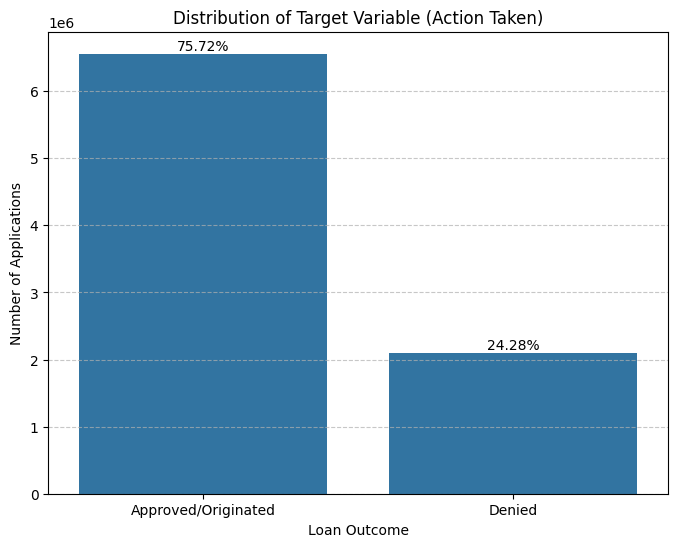

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get counts and percentages
counts = df['action_taken'].value_counts()
props = df['action_taken'].value_counts(normalize=True) * 100

# Create properly aligned DataFrame
plot_df = pd.DataFrame({
    'Action Taken': ['Approved/Originated', 'Denied'],
    'Count': [counts.get(1, 0), counts.get(0, 0)],
    'Percentage': [props.get(1, 0), props.get(0, 0)]
})

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Action Taken', y='Count', data=plot_df)

# Add labels
for index, row in plot_df.iterrows():
    plt.text(index, row['Count'], f"{row['Percentage']:.2f}%",
             ha='center', va='bottom')

plt.title('Distribution of Target Variable (Action Taken)')
plt.xlabel('Loan Outcome')
plt.ylabel('Number of Applications')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Feature Selection

Based on the project goals and initial data exploration, we will select a subset of features for the model. This step reduces dimensionality and focuses on the most relevant variables.

In [7]:
selected_columns = [
    'loan_amount',
    'income',
    'loan_type',
    'loan_purpose',
    'applicant_credit_score_type',
    'derived_ethnicity',
    'derived_race',
    'derived_sex',
    'action_taken' # Changed from 'target_action' to 'action_taken'
]

# Create a new DataFrame with only the selected columns
df = df[selected_columns].copy()

print("Shape of DataFrame after column selection:", df.shape)
print("Columns in the DataFrame:", df.columns.tolist())

Shape of DataFrame after column selection: (8661777, 9)
Columns in the DataFrame: ['loan_amount', 'income', 'loan_type', 'loan_purpose', 'applicant_credit_score_type', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken']


### Initial Data Exploration and Cleaning

Let's start by examining the data types and checking for missing values to get a better understanding of our dataset.

In [8]:
df.head(10)

,loan_amount,income,loan_type,loan_purpose,applicant_credit_score_type,derived_ethnicity,derived_race,derived_sex,action_taken
0,655000,300.0,1,31,1,Not Hispanic or Latino,White,Male,1
1,295000,85.0,1,1,2,Not Hispanic or Latino,White,Joint,1
2,275000,85.0,1,31,3,Not Hispanic or Latino,White,Female,1
3,545000,276.0,1,1,9,Joint,White,Joint,1
4,365000,90.0,1,31,2,Not Hispanic or Latino,White,Male,1
5,185000,97.0,1,1,3,Not Hispanic or Latino,White,Joint,1
6,425000,110.0,1,1,9,Not Hispanic or Latino,White,Joint,1
7,905000,235.0,1,1,3,Ethnicity Not Available,Race Not Available,Male,1
8,285000,68.0,1,1,3,Not Hispanic or Latino,Asian,Male,1
9,215000,73.0,1,1,3,Hispanic or Latino,White,Male,1


### Checking for Missing Values after Feature Selection

In [9]:
# Display data types of each column
print("Data Types:")
display(df.info())

# Calculate the percentage of missing values for each column
missing_percentage = df.isnull().sum() / len(df) * 100

# Display columns with missing values, sorted in descending order
missing_data = pd.DataFrame({
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

print("\nColumns with Missing Values:")
display(missing_data[missing_data['Missing Percentage'] > 0])

Data Types:
<class 'pandas.core.frame.DataFrame'>
Index: 8661777 entries, 0 to 12259155
Data columns (total 9 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   loan_amount                  int64  
 1   income                       float64
 2   loan_type                    int64  
 3   loan_purpose                 int64  
 4   applicant_credit_score_type  int64  
 5   derived_ethnicity            object 
 6   derived_race                 object 
 7   derived_sex                  object 
 8   action_taken                 int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 660.8+ MB


None


Columns with Missing Values:


,Missing Percentage
income,6.298153


In [10]:
# Drop columns with any missing values
df_dropped = df.dropna(axis=1)

print("Shape of DataFrame after dropping columns with missing values:", df_dropped.shape)
print("Columns remaining:", df_dropped.columns.tolist())

df = df_dropped

Shape of DataFrame after dropping columns with missing values: (8661777, 8)
Columns remaining: ['loan_amount', 'loan_type', 'loan_purpose', 'applicant_credit_score_type', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken']


In [11]:
df = df_dropped.copy() # Revert df to the state before one-hot encoding
print("DataFrame reverted to original categorical columns. Shape:", df.shape)
print("Columns in DataFrame:", df.columns.tolist())

DataFrame reverted to original categorical columns. Shape: (8661777, 8)
Columns in DataFrame: ['loan_amount', 'loan_type', 'loan_purpose', 'applicant_credit_score_type', 'derived_ethnicity', 'derived_race', 'derived_sex', 'action_taken']


In [12]:
df.shape

(8661777, 8)

Data Type Conversion

In [13]:
# Convert numeric variables
df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")

# Convert categorical variables
cat_cols = ["derived_race", "derived_sex"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Convert specified columns to numeric, coercing errors
numeric_cols = ['loan_amount']

for col in numeric_cols:
    if col in df.columns:
        # Check if the column is already numeric before converting to avoid warnings/redundancy
        if not pd.api.types.is_numeric_dtype(df[col]):
            print(f"Converting '{col}' to numeric...")
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            print(f"'{col}' is already numeric.")
    else:
        print(f"'{col}' not found in DataFrame.")

# Convert specified columns to categorical
categorical_cols = ['derived_race', 'derived_ethnicity', 'derived_sex']

for col in categorical_cols:
    if col in df.columns:
        # Check if the column is already categorical
        if not pd.api.types.is_categorical_dtype(df[col]):
            print(f"Converting '{col}' to category...")
            df[col] = df[col].astype('category')
        else:
            print(f"'{col}' is already categorical.")
    else:
        print(f"'{col}' not found in DataFrame.")

# Display the data types after conversion to verify
print("\nData types after conversion:")
df.info()

# Display the first few rows to observe the changes
print("\nFirst 5 rows of DataFrame after conversion:")
df.head()

'loan_amount' is already numeric.
'derived_race' is already categorical.
Converting 'derived_ethnicity' to category...
'derived_sex' is already categorical.

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 8661777 entries, 0 to 12259155
Data columns (total 8 columns):
 #   Column                       Dtype   
---  ------                       -----   
 0   loan_amount                  int64   
 1   loan_type                    int64   
 2   loan_purpose                 int64   
 3   applicant_credit_score_type  int64   
 4   derived_ethnicity            category
 5   derived_race                 category
 6   derived_sex                  category
 7   action_taken                 int64   
dtypes: category(3), int64(5)
memory usage: 421.3 MB

First 5 rows of DataFrame after conversion:


,loan_amount,loan_type,loan_purpose,applicant_credit_score_type,derived_ethnicity,derived_race,derived_sex,action_taken
0,655000,1,31,1,Not Hispanic or Latino,White,Male,1
1,295000,1,1,2,Not Hispanic or Latino,White,Joint,1
2,275000,1,31,3,Not Hispanic or Latino,White,Female,1
3,545000,1,1,9,Joint,White,Joint,1
4,365000,1,31,2,Not Hispanic or Latino,White,Male,1


SEX MAPPING

In [14]:
sex_map = {
    'Female': 'Female',
    'Male': 'Male',
    'Joint': 'Joint',
    'Sex Not Available': 'Unknown' # Added this line
}

df['sex'] = df['derived_sex'].map(sex_map)
df['sex'] = df['sex'].fillna('Unknown')

print(df['sex'].value_counts())

sex
Joint      3003110
Male       2934484
Female     1951980
Unknown     772203
Name: count, dtype: int64


In [15]:
sex_summary = df.groupby('sex')['action_taken'].agg(['count', 'mean'])
sex_summary = sex_summary.rename(columns={
    'count': 'Total Applications',
    'mean': 'Approval Rate'
})

print(sex_summary)

         Total Applications  Approval Rate
sex                                       
Female              1951980       0.707111
Joint               3003110       0.816699
Male                2934484       0.735657
Unknown              772203       0.733798


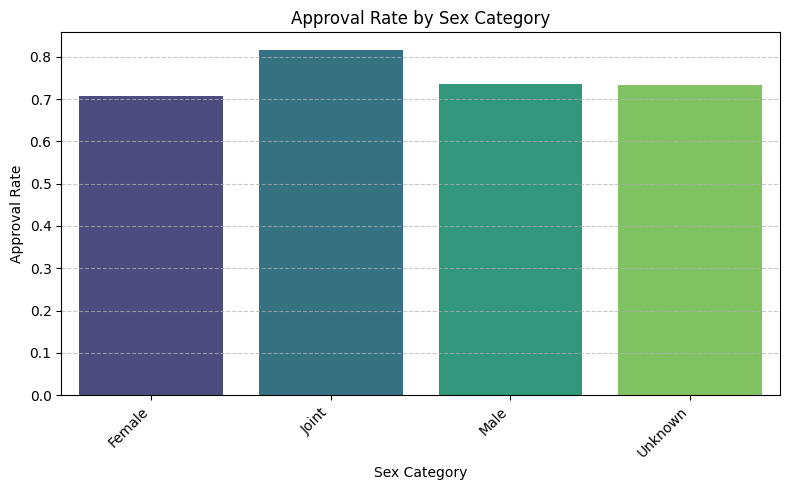

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x=sex_summary.index, y='Approval Rate', data=sex_summary, palette='viridis')
plt.ylabel('Approval Rate')
plt.xlabel('Sex Category')
plt.title('Approval Rate by Sex Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

ETHNICITY MAPPING

In [17]:
df['ethnicity'] = df['derived_ethnicity'].replace({
    'Not Hispanic or Latino': 'Non-Hispanic',
    'Hispanic or Latino': 'Hispanic',
    'Ethnicity Not Available': 'Unknown',
    'Free Form Text Only': 'Unknown'
})

In [18]:
df['ethnicity'].value_counts()

,count
ethnicity,
Non-Hispanic,5968142
Unknown,1414362
Hispanic,1055891
Joint,223382


In [19]:
approval_by_ethnicity = df.groupby('ethnicity')['action_taken'].mean().reset_index()
approval_by_ethnicity.columns = ['Ethnicity Category', 'Approval Rate']
approval_by_ethnicity['Approval Rate'] = approval_by_ethnicity['Approval Rate'] * 100

print("Approval Rate by Ethnicity Category:")
display(approval_by_ethnicity.sort_values(by='Approval Rate', ascending=False))

Approval Rate by Ethnicity Category:


,Ethnicity Category,Approval Rate
2,Joint,79.260639
3,Non-Hispanic,77.347623
0,Unknown,72.883745
1,Hispanic,69.534355


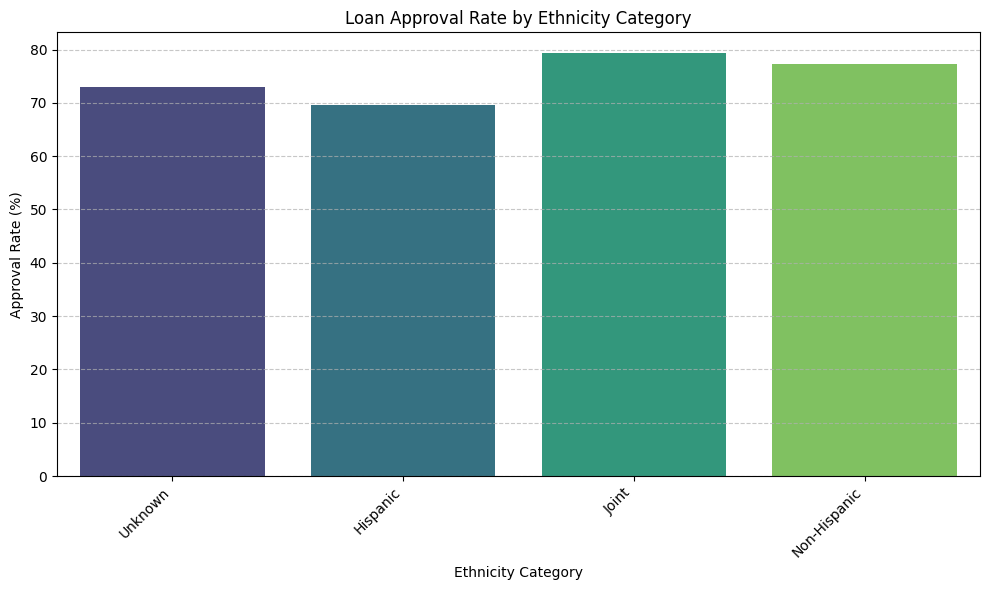

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Ethnicity Category', y='Approval Rate', data=approval_by_ethnicity.sort_values(by='Approval Rate', ascending=False), palette='viridis')
plt.title('Loan Approval Rate by Ethnicity Category')
plt.xlabel('Ethnicity Category')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

RACE MAPPING


In [21]:
race_map = {
    'Black or African American': 'Black',
    'White': 'White',
    'Asian': 'Asian',
    'American Indian or Alaska Native': 'Native American',
    'Native Hawaiian or Other Pacific Islander': 'Pacific Islander',
    '2 or more minority races': 'Multiracial',
    'Joint': 'Joint',
    'Free Form Text Only': 'Other'
}

In [22]:
# Apply the race mapping and handle any unmapped categories (e.g., those removed in earlier cleanup)
df['race'] = df['derived_race'].map(race_map)

# Convert to categorical and add 'Other' to categories before filling NaNs
df['race'] = df['race'].astype('category')
if 'Other' not in df['race'].cat.categories:
    df['race'] = df['race'].cat.add_categories('Other')

df['race'] = df['race'].fillna('Other') # Fill any remaining NaNs (e.g., 'Race Not Available' or 'Free Form Text Only' if not mapped) with 'Other'

print("Value counts for the new 'race' column:")
df['race'].value_counts()

Value counts for the new 'race' column:


,count
race,
White,5550899
Other,1528239
Black,762461
Asian,524984
Joint,189064
Native American,63158
Multiracial,21855
Pacific Islander,21117


In [23]:
approval_by_race_mapped = df.groupby('race')['action_taken'].mean().reset_index()
approval_by_race_mapped.columns = ['Race Category', 'Approval Rate']
approval_by_race_mapped['Approval Rate'] = approval_by_race_mapped['Approval Rate'] * 100

print("Approval Rate by Mapped Race Category:")
display(approval_by_race_mapped.sort_values(by='Approval Rate', ascending=False))

Approval Rate by Mapped Race Category:


,Race Category,Approval Rate
2,Joint,80.457411
0,Asian,78.729257
7,White,78.192127
5,Other,72.193878
1,Black,63.343174
4,Native American,62.965895
3,Multiracial,61.972089
6,Pacific Islander,61.301321


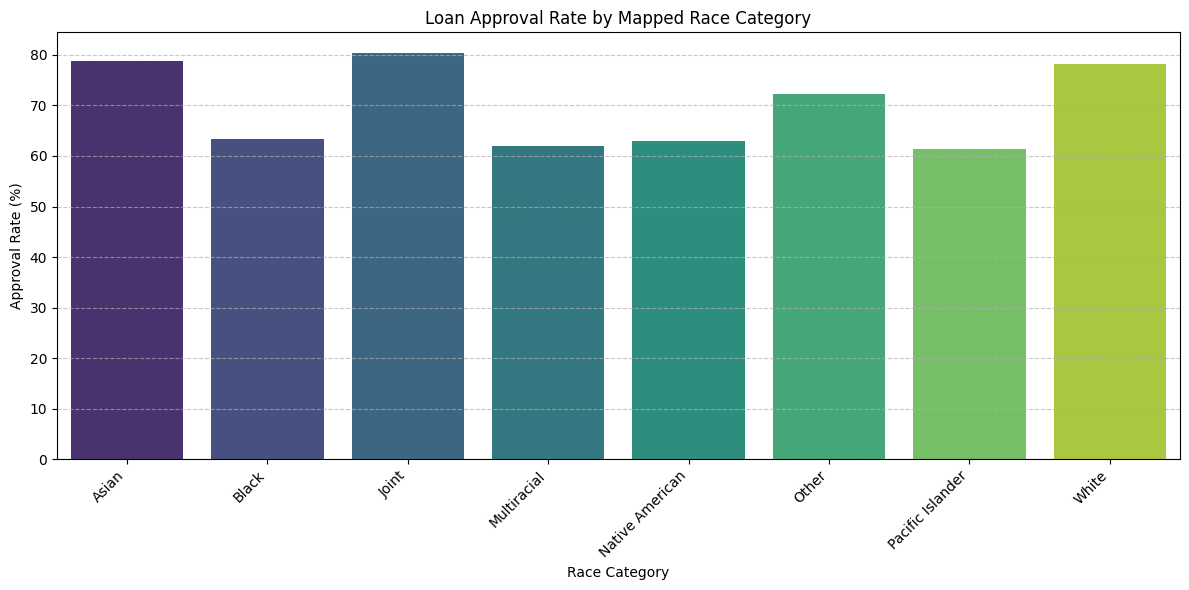

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Race Category', y='Approval Rate', data=approval_by_race_mapped.sort_values(by='Approval Rate', ascending=False), palette='viridis')
plt.title('Loan Approval Rate by Mapped Race Category')
plt.xlabel('Race Category')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

CROSS TABULATION

In [25]:
gender_race_xtab = pd.crosstab(df['sex'], df['race'])
display(gender_race_xtab)

race,Asian,Black,Joint,Multiracial,Native American,Other,Pacific Islander,White
sex,,,,,,,,
Female,120909,317014,5782,7674,20651,197271,5754,1276925
Joint,166857,154294,175977,3949,9632,259464,4977,2227960
Male,233956,286373,6549,9667,32278,332454,10094,2023113
Unknown,3262,4780,756,565,597,739050,292,22901


In [26]:
race_ethnicity_xtab = pd.crosstab(df['race'], df['ethnicity'])
display(race_ethnicity_xtab)

ethnicity,Unknown,Hispanic,Joint,Non-Hispanic
race,,,,
Asian,24475,14535,7455,478519
Black,38786,32304,10618,680753
Joint,5734,10926,30019,142385
Multiracial,1516,4746,1440,14153
Native American,4762,23207,1679,33510
Other,1180057,198234,15682,134266
Pacific Islander,1295,5773,652,13397
White,157737,766166,155837,4471159


In [27]:
sex_ethnicity_xtab = pd.crosstab(df['sex'], df['ethnicity'])
display(sex_ethnicity_xtab)

ethnicity,Unknown,Hispanic,Joint,Non-Hispanic
sex,,,,
Female,166213,280621,12511,1492635
Joint,229653,295256,192531,2285670
Male,286473,472320,17436,2158255
Unknown,732023,7694,904,31582


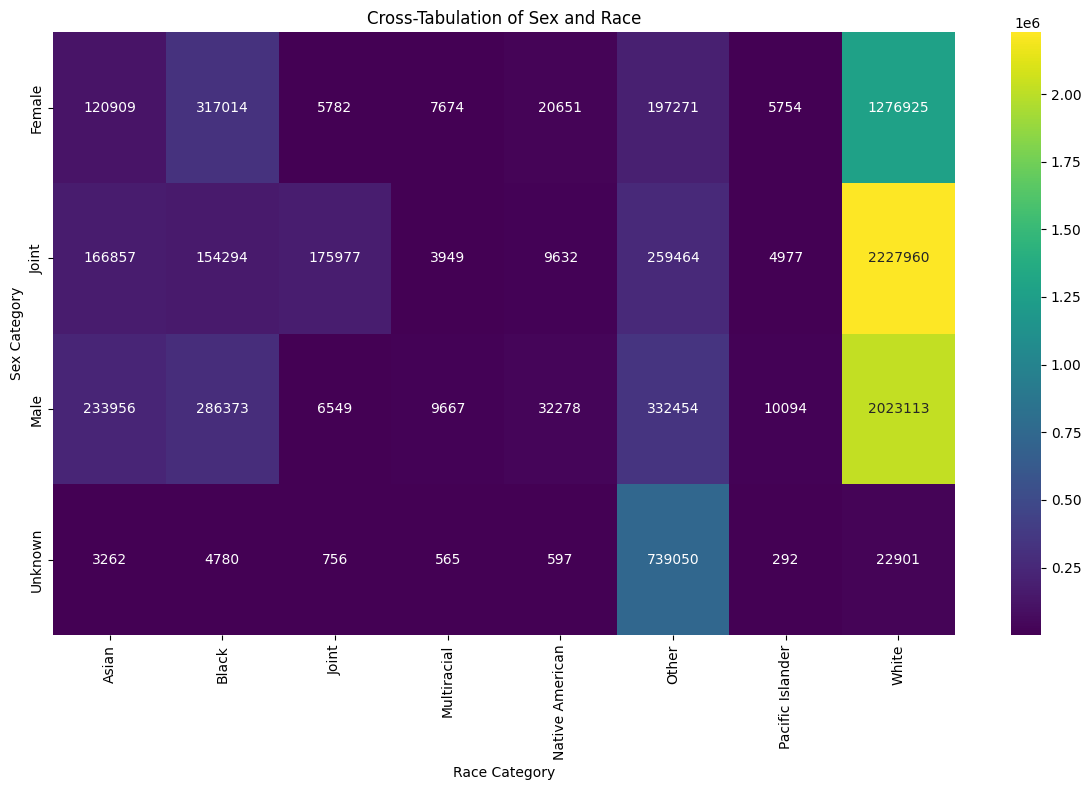

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(gender_race_xtab, annot=True, fmt='d', cmap='viridis')
plt.title('Cross-Tabulation of Sex and Race')
plt.xlabel('Race Category')
plt.ylabel('Sex Category')
plt.tight_layout()
plt.show()

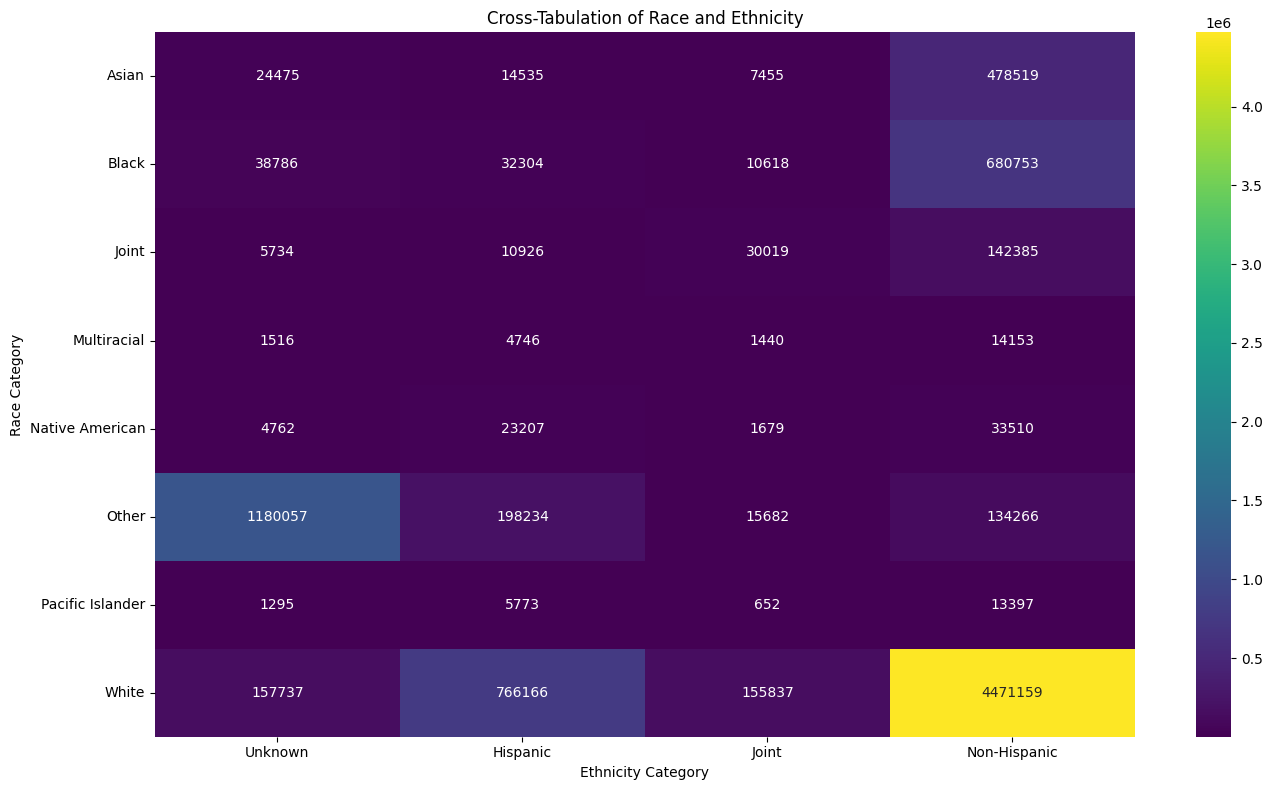

In [29]:
plt.figure(figsize=(14, 8))
sns.heatmap(race_ethnicity_xtab, annot=True, fmt='d', cmap='viridis')
plt.title('Cross-Tabulation of Race and Ethnicity')
plt.xlabel('Ethnicity Category')
plt.ylabel('Race Category')
plt.tight_layout()
plt.show()

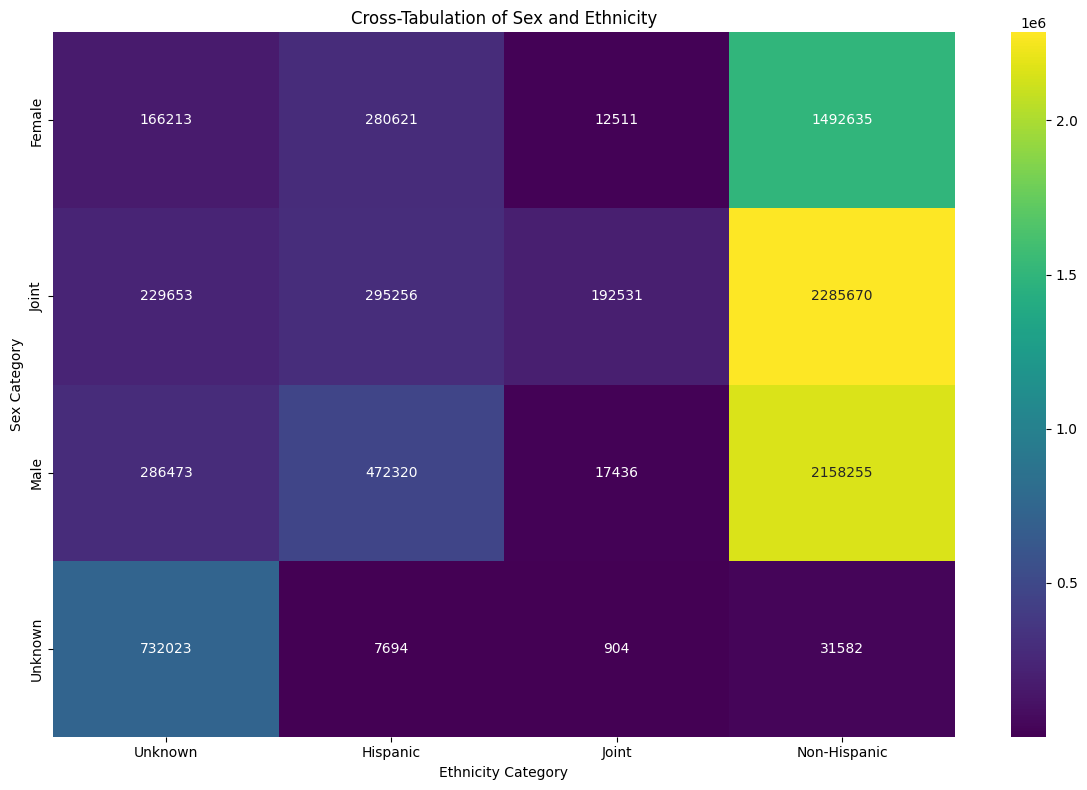

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(sex_ethnicity_xtab, annot=True, fmt='d', cmap='viridis')
plt.title('Cross-Tabulation of Sex and Ethnicity')
plt.xlabel('Ethnicity Category')
plt.ylabel('Sex Category')
plt.tight_layout()
plt.show()

LOAN AMOUNT

In [31]:
correlation = df['loan_amount'].corr(df['action_taken'])
print(f"Correlation between Loan Amount and Approval Status: {correlation:.4f}")

Correlation between Loan Amount and Approval Status: 0.0253


The correlation between Loan Amount and Approval Status is 0.1079. This indicates a very weak positive linear relationship. In practical terms, this means that while there's a slight tendency for loan amounts to be higher for approved loans, the loan amount itself is not a strong predictor of approval status.

### Approval Rate by Loan Amount Range

If we get approval by loan amount that a bit narrow so we will use the loam amount range

In [92]:
loan_amount_ranges = [0, 50000, 100000, 200000, 300000, 500000, 1000000, df['loan_amount'].max()]
labels = ['0-50k', '50k-100k', '100k-200k', '200k-300k', '300k-500k', '500k-1M', '1M+']

# Create a new column 'loan_amount_range'
df['loan_amount_range'] = pd.cut(df['loan_amount'], bins=loan_amount_ranges, labels=labels, right=False)

# Calculate approval rate and count by loan amount range
approval_by_loan_amount_range = df.groupby('loan_amount_range')['action_taken'].agg(['mean', 'count']).reset_index()
approval_by_loan_amount_range.rename(columns={'mean': 'Approval Rate', 'count': 'Number of Applications'}, inplace=True)
approval_by_loan_amount_range['Approval Rate'] = approval_by_loan_amount_range['Approval Rate'] * 100

print("Approval Rate and Count by Loan Amount Range:")
display(approval_by_loan_amount_range.sort_values(by='Approval Rate', ascending=False))

Approval Rate and Count by Loan Amount Range:


,loan_amount_range,Approval Rate,Number of Applications
5,500k-1M,87.102653,900503
6,1M+,85.574154,199302
4,300k-500k,85.448835,1762498
3,200k-300k,81.373601,1570631
2,100k-200k,71.629662,1958750
1,50k-100k,62.565911,1353141
0,0-50k,62.123167,916951


This suggests that larger loan applications tend to have a higher likelihood of approval in this dataset. This could be due to various factors, such as applicants for larger loans typically having stronger financial profiles, or institutions having different risk assessment criteria for different loan tiers.

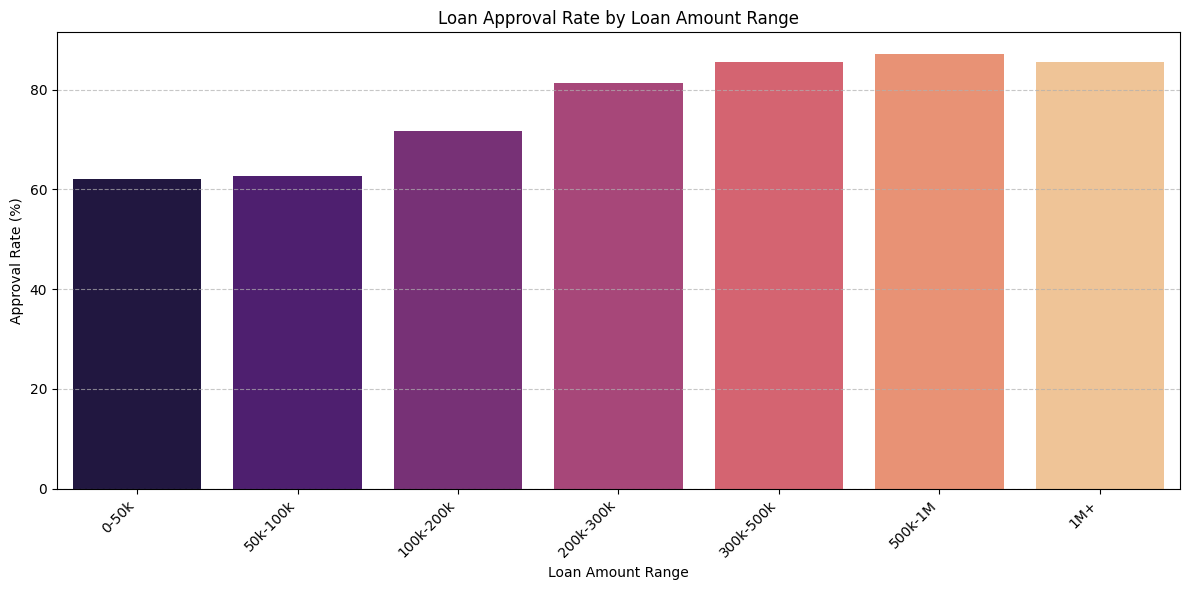

In [93]:
plt.figure(figsize=(12, 6))
sns.barplot(x='loan_amount_range', y='Approval Rate', data=approval_by_loan_amount_range, palette='magma')
plt.title('Loan Approval Rate by Loan Amount Range')
plt.xlabel('Loan Amount Range')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

CREDIT SCORE TYPE

In [94]:
# Calculate approval rate by applicant credit score type
approval_by_credit_score_type = df.groupby('applicant_credit_score_type')['action_taken'].mean().reset_index()
approval_by_credit_score_type.columns = ['Credit Score Type', 'Approval Rate']
approval_by_credit_score_type['Approval Rate'] = approval_by_credit_score_type['Approval Rate'] * 100

print("Approval Rate by Applicant Credit Score Type:")
display(approval_by_credit_score_type.sort_values(by='Approval Rate', ascending=False))

Approval Rate by Applicant Credit Score Type:


,Credit Score Type,Approval Rate
14,1111,86.899990
4,5,85.985748
2,3,83.516311
0,1,79.611011
6,7,78.860306
1,2,78.497061
8,9,73.104510
11,13,68.180084
13,15,65.728420
9,11,65.586052


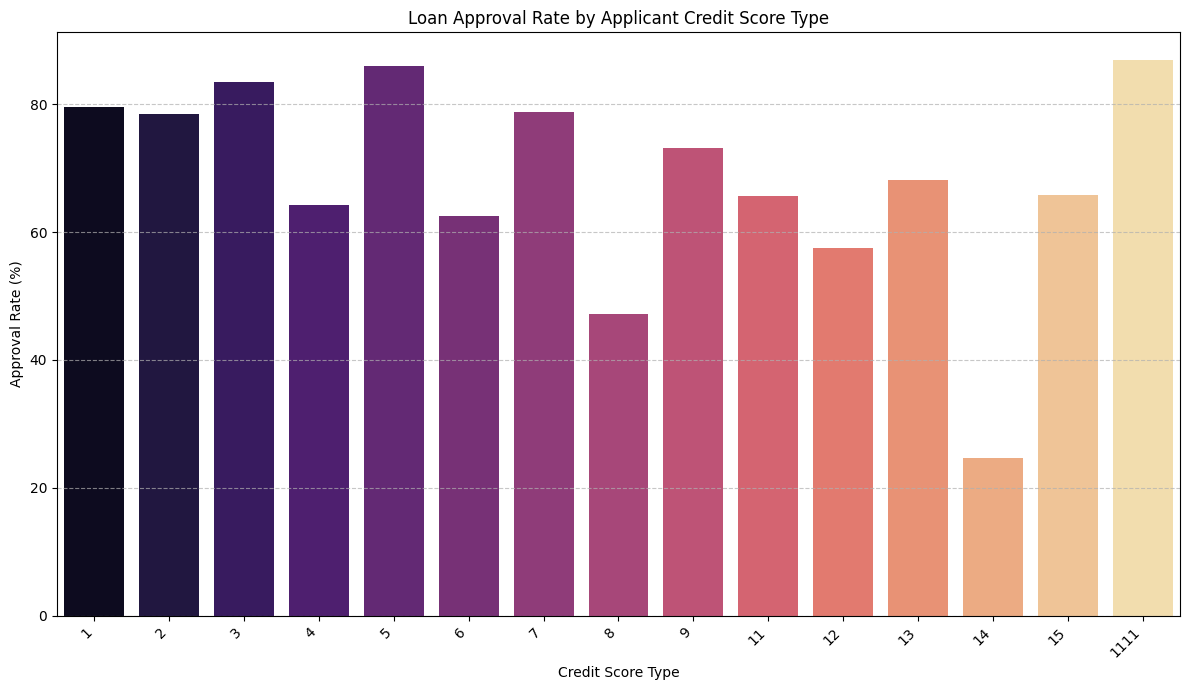

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Credit Score Type', y='Approval Rate', data=approval_by_credit_score_type.sort_values(by='Approval Rate', ascending=False), palette='magma')
plt.title('Loan Approval Rate by Applicant Credit Score Type')
plt.xlabel('Credit Score Type')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The analysis shows substantial variation in approval rates across different applicant credit score types, ranging from approximately 24.7% to 86.9%.

This indicates that the model places significant weight on the type of credit score used when predicting loan approval outcomes.

Higher approval rates are associated with certain credit score types, suggesting that these scoring systems may reflect stronger or more complete credit profiles. Conversely, some credit score types are associated with much lower approval rates, indicating potential disadvantages for applicants using those systems

LOAN PURPOSE

In [89]:
# Calculate approval rate by loan purpose
approval_by_loan_purpose = df.groupby('loan_purpose')['action_taken'].mean().reset_index()
approval_by_loan_purpose.columns = ['Loan Purpose', 'Approval Rate']
approval_by_loan_purpose['Approval Rate'] = approval_by_loan_purpose['Approval Rate'] * 100

print("\nApproval Rate by Loan Purpose:")
display(approval_by_loan_purpose.sort_values(by='Approval Rate', ascending=False))


Approval Rate by Loan Purpose:


,Loan Purpose,Approval Rate
0,1,85.553882
4,31,77.134230
3,5,74.474215
5,32,67.290812
1,2,62.624361
2,4,57.776410


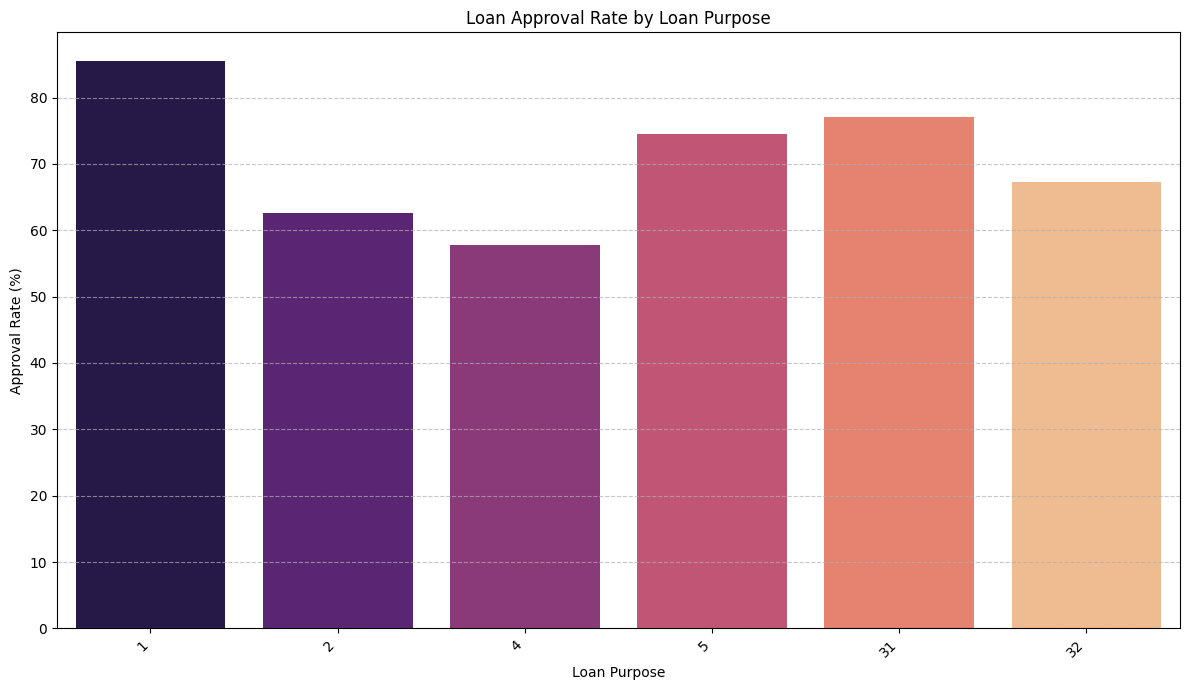

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Loan Purpose', y='Approval Rate', data=approval_by_loan_purpose.sort_values(by='Approval Rate', ascending=False), palette='magma')
plt.title('Loan Approval Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The analysis shows that loan approval rates vary significantly across different loan purposes, ranging from approximately 57.8% to 85.6%.

This indicates that loan purpose is a strong predictor in the model, with certain purposes being more likely to receive approval. This likely reflects underlying differences in risk profiles, borrower characteristics, and lending policies associated with each loan type.

General Trend: For all ethnicity groups, the loan approval rate generally increases as the loan amount bin increases. This suggests that larger loans tend to have a higher approval rate.
Ethnicity Differences: Within similar loan amount bins, there are differences in approval rates across ethnic groups. For instance, in the smallest loan bin (4999.999, 95000.0]), 'Hispanic' applicants have the lowest approval rate (52.72%), while 'Non-Hispanic' applicants have a higher rate (64.90%). 'Joint' applicants consistently show the highest approval rates across most loan bins, particularly for larger loan amounts

TRAIN TEST SPLIT

In [57]:
from sklearn.model_selection import train_test_split

# Define the features and target based on the user's input
features = [
    'loan_amount',
    'loan_type',
    'loan_purpose',
    'applicant_credit_score_type',
    'ethnicity',
    'race',
    'sex',
    'loan_amount_range' # Added loan_amount_range to features
]
target_variable = 'action_taken'

# Prepare X (features) and y (target)
X = df[features].copy()
y = df[target_variable].copy()

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate total rows for percentage calculation
total_rows = len(X)

print(f"Train: {X_train.shape} ({len(X_train)/total_rows:.1%} rows, 80.0%)")
print(f"Test: {X_test.shape} ({len(X_test)/total_rows:.1%} rows, 20.0%)")

print("\nValue counts for y_train (stratified check):")
display(y_train.value_counts(normalize=True))

print("\nValue counts for y_test (stratified check):")
display(y_test.value_counts(normalize=True))

Train: (6929421, 8) (80.0% rows, 80.0%)
Test: (1732356, 8) (20.0% rows, 20.0%)

Value counts for y_train (stratified check):


,proportion
action_taken,
1,0.757156
0,0.242844



Value counts for y_test (stratified check):


,proportion
action_taken,
1,0.757156
0,0.242844


### Fairness Analysis by Ethnic Group


In [50]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define feature groups based on the X_train columns
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

# 1. Gradient Boosted Trees (GBT) Pipeline
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=50,  # Reduced from 200 for faster training
        max_depth=2,      # Reduced from 4 for faster training
        random_state=42
    ))
])

print("\nFitting Gradient Boosted Trees...")
gbt_pipeline.fit(X_train, y_train)
print("Gradient Boosted Trees Pipeline trained successfully!")

# 2. Random Forest Classifier Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)) # Reduced from 100 for faster training
])

print("\nFitting Random Forest Classifier...")
rf_pipeline.fit(X_train, y_train)
print("Random Forest Classifier Pipeline trained successfully!")

print("\nYou now have 'gbt_pipeline' and 'rf_pipeline' available for further evaluation.")

Numeric features: ['loan_amount', 'loan_type', 'loan_purpose', 'applicant_credit_score_type']
Categorical features: ['ethnicity', 'race', 'sex']

Fitting Gradient Boosted Trees...
Gradient Boosted Trees Pipeline trained successfully!

Fitting Random Forest Classifier...
Random Forest Classifier Pipeline trained successfully!

You now have 'gbt_pipeline' and 'rf_pipeline' available for further evaluation.


In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model_performance_by_group(pipeline, X_test_group, y_test_group, model_name, group_name):
    """
    Calculates and prints the confusion matrix and various performance metrics
    for a given classification pipeline for a specific group.

    Args:
        pipeline: Trained sklearn pipeline with a predict_proba method.
        X_test_group: Test features DataFrame for a specific group.
        y_test_group: True labels for the test set of a specific group.
        model_name: Name of the model for printing.
        group_name: Name of the group for printing.
    """
    if len(y_test_group) == 0:
        print(f"No data for {group_name} in {model_name}. Skipping evaluation.")
        return

    predictions_proba = pipeline.predict_proba(X_test_group)[:, 1]
    predictions_binary = (predictions_proba > 0.5).astype(int)

    # Create the Confusion Matrix
    overall_cm = confusion_matrix(y_test_group, predictions_binary)

    print(f"â”€â”€ Confusion Matrix ({model_name} - {group_name}) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€")
    print(overall_cm)

    # Extract values for easier metric calculation
    tn, fp, fn, tp = overall_cm.ravel()

    # Calculate metrics
    accuracy = accuracy_score(y_test_group, predictions_binary)
    precision = precision_score(y_test_group, predictions_binary, zero_division=0)
    recall = recall_score(y_test_group, predictions_binary, zero_division=0)

    # False Positive Rate (FPR) and False Negative Rate (FNR)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    # Print metrics
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"FPR       : {fpr:.3f}")
    print(f"FNR       : {fnr:.3f}")
    print("-" * 80)


ethnic_groups = X_test['ethnicity'].unique()

print("\n--- Evaluating GBT Model by Ethnicity ---")
for group in ethnic_groups:
    group_indices = X_test['ethnicity'] == group
    X_test_group = X_test[group_indices]
    y_test_group = y_test[group_indices]
    evaluate_model_performance_by_group(gbt_pipeline, X_test_group, y_test_group, "Gradient Boosting Tree", group)

print("\n--- Evaluating Random Forest Model by Ethnicity ---")
for group in ethnic_groups:
    group_indices = X_test['ethnicity'] == group
    X_test_group = X_test[group_indices]
    y_test_group = y_test[group_indices]
    evaluate_model_performance_by_group(rf_pipeline, X_test_group, y_test_group, "Random Forest", group)



--- Evaluating GBT Model by Ethnicity ---
â”€â”€ Confusion Matrix (Gradient Boosting Tree - Unknown) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
[[  6273  70492]
 [  3875 202115]]
Accuracy  : 0.737
Precision : 0.741
Recall    : 0.981
FPR       : 0.918
FNR       : 0.019
--------------------------------------------------------------------------------
â”€â”€ Confusion Matrix (Gradient Boosting Tree - Non-Hispanic) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
[[ 15130 254908]
 [  8932 914352]]
Accuracy  : 0.779
Precision : 0.782
Recall    : 0.990
FPR       : 0.944
FNR       : 0.010
--------------------------------------------------------------------------------
â”€â”€ Confusion Matrix (Gradient Boosting Tree - Hispanic) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
[[  9728  54954]
 [  4775 141963]]
Accuracy  : 0.717
Precision : 0.721
Recall    : 0.967
FPR       : 0.850
FNR       : 0.033
------------------------------------------------------------------------

### Summary of Fairness Analysis by Ethnic Group

In [52]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def collect_model_performance_by_group(pipeline, X_test, y_test, model_name, group_column):
    """
    Collects performance metrics for a given classification pipeline across specified groups.

    Args:
        pipeline: Trained sklearn pipeline with a predict_proba method.
        X_test: Test features DataFrame.
        y_test: True labels for the test set.
        model_name: Name of the model.
        group_column: The column name in X_test to group by (e.g., 'ethnicity', 'race', 'sex', 'loan_bin').

    Returns:
        A list of dictionaries, each containing metrics for a specific group.
    """
    results = []
    groups = X_test[group_column].unique()

    for group in groups:
        group_indices = X_test[group_column] == group
        X_test_group = X_test[group_indices]
        y_test_group = y_test[group_indices]

        if len(y_test_group) == 0:
            continue

        predictions_proba = pipeline.predict_proba(X_test_group)[:, 1]
        predictions_binary = (predictions_proba > 0.5).astype(int)

        overall_cm = confusion_matrix(y_test_group, predictions_binary)
        tn, fp, fn, tp = overall_cm.ravel()

        accuracy = accuracy_score(y_test_group, predictions_binary)
        precision = precision_score(y_test_group, predictions_binary, zero_division=0)
        recall = recall_score(y_test_group, predictions_binary, zero_division=0)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        results.append({
            'Model': model_name,
            group_column.replace('_', ' ').title(): group,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'FPR': fpr,
            'FNR': fnr
        })
    return results


In [53]:
# Collect results for GBT Model by Ethnicity
gbt_ethnicity_results = collect_model_performance_by_group(gbt_pipeline, X_test, y_test, "Gradient Boosting Tree", 'ethnicity')

# Collect results for Random Forest Model by Ethnicity
rf_ethnicity_results = collect_model_performance_by_group(rf_pipeline, X_test, y_test, "Random Forest", 'ethnicity')

# Combine and display results
all_ethnicity_results_df = pd.DataFrame(gbt_ethnicity_results + rf_ethnicity_results)

print("\n--- Combined Fairness Analysis Summary Table (by Ethnicity) ---")
display(all_ethnicity_results_df.sort_values(by=['Model', 'Ethnicity']).reset_index(drop=True))


--- Combined Fairness Analysis Summary Table (by Ethnicity) ---


,Model,Ethnicity,Accuracy,Precision,Recall,FPR,FNR
0,Gradient Boosting Tree,Hispanic,0.717487,0.720928,0.967459,0.849603,0.032541
1,Gradient Boosting Tree,Joint,0.800241,0.800649,0.996859,0.961117,0.003141
2,Gradient Boosting Tree,Non-Hispanic,0.778903,0.781992,0.990326,0.943971,0.009674
3,Gradient Boosting Tree,Unknown,0.736991,0.741415,0.981188,0.918283,0.018812
4,Random Forest,Hispanic,0.741008,0.776252,0.880699,0.575894,0.119301
5,Random Forest,Joint,0.793754,0.829177,0.932627,0.743999,0.067373
6,Random Forest,Non-Hispanic,0.789956,0.809359,0.952997,0.767496,0.047003
7,Random Forest,Unknown,0.760209,0.785890,0.922054,0.674083,0.077946


### Fairness Analysis by Race

In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def compute_metrics_dict(pipeline, X, y, group_label):
    predictions_proba = pipeline.predict_proba(X)[:, 1]
    predictions_binary = (predictions_proba > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, predictions_binary).ravel()

    accuracy = accuracy_score(y, predictions_binary)
    precision = precision_score(y, predictions_binary, zero_division=0)
    recall = recall_score(y, predictions_binary, zero_division=0)
    f1 = f1_score(y, predictions_binary, zero_division=0)

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    return {
        "race": group_label,
        "n": len(y),
        "accuracy": accuracy,
        "FPR": fpr,
        "FNR": fnr,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [54]:
def evaluate_by_group_table(pipeline, X_test, y_test, group_col, model_name):
    results = []

    unique_groups = X_test[group_col].unique()

    for group in unique_groups:
        idx = X_test[group_col] == group

        X_group = X_test[idx]
        y_group = y_test[idx]

        metrics = compute_metrics_dict(pipeline, X_group, y_group, group)
        results.append(metrics)

    df_results = pd.DataFrame(results)

    print(f"\n{model_name}\n")
    display(df_results.sort_values("race"))

In [46]:
evaluate_by_group_table(gbt_pipeline, X_test, y_test, "race", "Gradient-Boosted Tree")

evaluate_by_group_table(rf_pipeline, X_test, y_test, "race", "Random Forest")


Gradient-Boosted Tree



,race,n,accuracy,FPR,FNR,precision,recall,f1
4,Asian,105242,0.798493,0.898738,0.012798,0.802310,0.987202,0.885204
2,Black,152679,0.674055,0.739335,0.087742,0.681666,0.912258,0.780282
1,Joint,38038,0.807429,0.988981,0.001792,0.808190,0.998208,0.893204
7,Multiracial,4408,0.660163,0.840331,0.028340,0.650086,0.971660,0.778991
5,Native American,12714,0.669105,0.808280,0.049975,0.666375,0.950025,0.783312
3,Other,305501,0.731952,0.900507,0.023162,0.736952,0.976838,0.840106
6,Pacific Islander,4165,0.642497,0.838611,0.044392,0.636484,0.955608,0.764063
0,White,1109609,0.784143,0.980698,0.002754,0.784929,0.997246,0.878440



Random Forest



,race,n,accuracy,FPR,FNR,precision,recall,f1
4,Asian,105242,0.803520,0.664630,0.069774,0.837957,0.930226,0.881684
2,Black,152679,0.701583,0.499382,0.182617,0.739621,0.817383,0.776560
1,Joint,38038,0.801541,0.797170,0.055040,0.831889,0.944960,0.884827
7,Multiracial,4408,0.686025,0.439385,0.235922,0.736431,0.764078,0.750000
5,Native American,12714,0.690027,0.474098,0.213393,0.738187,0.786607,0.761628
3,Other,305501,0.757022,0.653649,0.083967,0.783521,0.916033,0.844611
6,Pacific Islander,4165,0.661465,0.464068,0.256837,0.711035,0.743163,0.726744
0,White,1109609,0.794870,0.806951,0.037448,0.810647,0.962552,0.880093


### Fairness Analysis by Sex

In [55]:
# Collect results for GBT Model by Sex
gbt_sex_results = collect_model_performance_by_group(gbt_pipeline, X_test, y_test, "Gradient Boosting Tree", 'sex')

# Collect results for Random Forest Model by Sex
rf_sex_results = collect_model_performance_by_group(rf_pipeline, X_test, y_test, "Random Forest", 'sex')

# Combine and display results
all_sex_results_df = pd.DataFrame(gbt_sex_results + rf_sex_results)

print("\n--- Combined Fairness Analysis Summary Table (by Sex) ---")
display(all_sex_results_df.sort_values(by=['Model', 'Sex']).reset_index(drop=True))



--- Combined Fairness Analysis Summary Table (by Sex) ---


,Model,Sex,Accuracy,Precision,Recall,FPR,FNR
0,Gradient Boosting Tree,Female,0.723182,0.726492,0.975659,0.885425,0.024341
1,Gradient Boosting Tree,Joint,0.818003,0.818511,0.998634,0.987773,0.001366
2,Gradient Boosting Tree,Male,0.746475,0.750742,0.981255,0.907531,0.018745
3,Gradient Boosting Tree,Unknown,0.735961,0.742109,0.980377,0.934363,0.019623
4,Random Forest,Female,0.748362,0.775179,0.907033,0.634121,0.092967
5,Random Forest,Joint,0.820610,0.837085,0.968982,0.841262,0.031018
6,Random Forest,Male,0.761984,0.786884,0.927827,0.699993,0.072173
7,Random Forest,Unknown,0.761574,0.782124,0.935140,0.714438,0.064860


### Fairness Analysis by Loan Amount Range

In [59]:
gbt_loan_bin_results = collect_model_performance_by_group(gbt_pipeline, X_test, y_test, "Gradient Boosting Tree", 'loan_amount_range')

rf_loan_bin_results = collect_model_performance_by_group(rf_pipeline, X_test, y_test, "Random Forest", 'loan_amount_range')

all_loan_bin_results_df = pd.DataFrame(gbt_loan_bin_results + rf_loan_bin_results)

print("\n--- Combined Fairness Analysis Summary Table (by Loan Amount Range) ---")
display(all_loan_bin_results_df.sort_values(by=['Model', 'Loan Amount Range']).reset_index(drop=True))


--- Combined Fairness Analysis Summary Table (by Loan Amount Range) ---


,Model,Loan Amount Range,Accuracy,Precision,Recall,FPR,FNR
0,Gradient Boosting Tree,0-50k,0.647476,0.647248,0.951327,0.851601,0.048673
1,Gradient Boosting Tree,100k-200k,0.724559,0.727324,0.984256,0.929867,0.015744
2,Gradient Boosting Tree,1M+,0.856635,0.856635,1.000000,1.000000,0.000000
3,Gradient Boosting Tree,200k-300k,0.814130,0.814429,0.999154,0.992450,0.000846
4,Gradient Boosting Tree,300k-500k,0.853969,0.854007,0.999940,0.999767,0.000060
5,Gradient Boosting Tree,500k-1M,0.871146,0.871178,0.999955,0.999914,0.000045
6,Gradient Boosting Tree,50k-100k,0.646640,0.647736,0.955804,0.872002,0.044196
7,Random Forest,0-50k,0.688158,0.707083,0.850724,0.578857,0.149276
8,Random Forest,100k-200k,0.744430,0.764293,0.929744,0.722553,0.070256
9,Random Forest,1M+,0.830585,0.867946,0.946191,0.860185,0.053809


Key Observations by Loan Amount Range:

0-50k & 50k-100k: Both models have lower accuracy in these ranges, with Random Forest showing a more balanced (but still high) FPR and a higher FNR than GBT. GBT maintains high recall but with a very high FPR.
100k-200k to 500k-1M+: Performance metrics generally improve significantly for both models. GBT continues to show extremely high recall and low FNR, often at the expense of a very high FPR. Random Forest remains more balanced.
In summary, the Gradient Boosting Tree model appears to be more prone to false positives, especially for larger loans, while being very good at not missing true positives. The Random Forest model offers a more balanced performance, with a better FPR but slightly lower recall for smaller loan amounts.

Fairness Analysis by Credit Score Type

**Reasoning**:
I need to perform the fairness analysis by 'applicant_credit_score_type' as instructed. This involves calling the `collect_model_performance_by_group` function for both GBT and Random Forest models, combining their results, and then displaying them in a sorted DataFrame.



In [98]:
gbt_credit_score_results = collect_model_performance_by_group(gbt_pipeline, X_test, y_test, "Gradient Boosting Tree", 'applicant_credit_score_type')

rf_credit_score_results = collect_model_performance_by_group(rf_pipeline, X_test, y_test, "Random Forest", 'applicant_credit_score_type')

all_credit_score_results_df = pd.DataFrame(gbt_credit_score_results + rf_credit_score_results)

print("\n--- Combined Fairness Analysis Summary Table (by Applicant Credit Score Type) ---")
display(all_credit_score_results_df.sort_values(by=['Model', 'Applicant Credit Score Type']).reset_index(drop=True))


--- Combined Fairness Analysis Summary Table (by Applicant Credit Score Type) ---


,Model,Applicant Credit Score Type,Accuracy,Precision,Recall,FPR,FNR
0,Gradient Boosting Tree,1,0.796314,0.796314,1.000000,1.000000,0.000000
1,Gradient Boosting Tree,2,0.785518,0.785518,1.000000,1.000000,0.000000
2,Gradient Boosting Tree,3,0.833852,0.833852,1.000000,1.000000,0.000000
3,Gradient Boosting Tree,4,0.636953,0.636953,1.000000,1.000000,0.000000
4,Gradient Boosting Tree,5,0.901099,0.901099,1.000000,1.000000,0.000000
5,Gradient Boosting Tree,6,0.615327,0.615327,1.000000,1.000000,0.000000
6,Gradient Boosting Tree,7,0.788270,0.788270,1.000000,1.000000,0.000000
7,Gradient Boosting Tree,8,0.575409,0.534586,0.799841,0.626517,0.200159
8,Gradient Boosting Tree,9,0.736649,0.737428,0.993956,0.964778,0.006044
9,Gradient Boosting Tree,11,0.649069,0.666242,0.930621,0.886033,0.069379


The analysis shows that model performance varies significantly across applicant credit score types. The Gradient Boosting Tree (GBT) model consistently exhibits extremely high recall (near 1.00) and very low false negative rates across most credit score types, indicating that it rarely misses approved applications.

However, this comes at the cost of extremely high false positive rates (often close to 1.00), meaning the model frequently predicts approval even when the loan is actually denied.

This pattern suggests that the GBT model lacks discrimination for certain credit score types and tends to over-approve applicants regardless of their true outcome.

### Fairness Analysis by Loan Purpose

In [99]:
gbt_loan_purpose_results = collect_model_performance_by_group(gbt_pipeline, X_test, y_test, "Gradient Boosting Tree", 'loan_purpose')

rf_loan_purpose_results = collect_model_performance_by_group(rf_pipeline, X_test, y_test, "Random Forest", 'loan_purpose')

all_loan_purpose_results_df = pd.DataFrame(gbt_loan_purpose_results + rf_loan_purpose_results)

print("\n--- Combined Fairness Analysis Summary Table (by Loan Purpose) ---")
display(all_loan_purpose_results_df.sort_values(by=['Model', 'Loan Purpose']).reset_index(drop=True))


--- Combined Fairness Analysis Summary Table (by Loan Purpose) ---


,Model,Loan Purpose,Accuracy,Precision,Recall,FPR,FNR
0,Gradient Boosting Tree,1,0.860498,0.861130,0.997855,0.952751,0.002145
1,Gradient Boosting Tree,2,0.647796,0.651254,0.943809,0.850096,0.056191
2,Gradient Boosting Tree,4,0.602613,0.598051,0.951030,0.873559,0.048970
3,Gradient Boosting Tree,5,0.768012,0.767103,0.998106,0.963855,0.001894
4,Gradient Boosting Tree,31,0.771500,0.776520,0.987646,0.953797,0.012354
5,Gradient Boosting Tree,32,0.671364,0.672969,0.994262,0.990764,0.005738
6,Random Forest,1,0.872375,0.885238,0.977547,0.750322,0.022453
7,Random Forest,2,0.662275,0.683745,0.858634,0.668000,0.141366
8,Random Forest,4,0.635399,0.649212,0.801921,0.592182,0.198079
9,Random Forest,5,0.821326,0.863309,0.909091,0.457831,0.090909


The analysis reveals that model performance also varies across loan purposes. The GBT model maintains high recall across most loan purposes, ensuring that approved applications are rarely missed.

However, similar to the credit score type results, this comes at the cost of very high false positive rates, indicating that the model frequently predicts approval even when loans are denied.

The Random Forest model demonstrates more balanced performance, with lower false positive rates, but shows weaker performance in certain categories such as Loan Purpose 4

## Model Training and Evaluation

In [62]:
from sklearn.metrics import log_loss

# Calculate log loss for GBT model
y_pred_proba_gbt = gbt_pipeline.predict_proba(X_test)
logloss_gbt = log_loss(y_test, y_pred_proba_gbt)
print(f"Log Loss for Gradient Boosting Tree: {logloss_gbt:.4f}")

# Calculate log loss for Random Forest model
y_pred_proba_rf = rf_pipeline.predict_proba(X_test)
logloss_rf = log_loss(y_test, y_pred_proba_rf)
print(f"Log Loss for Random Forest: {logloss_rf:.4f}")

Log Loss for Gradient Boosting Tree: 0.4920
Log Loss for Random Forest: 0.5849


A lower Log Loss value indicates a better-performing model. In this case, the Gradient Boosting Tree model has a lower Log Loss (0.4920) compared to the Random Forest model (0.5849). This suggests that the Gradient Boosting Tree model is more accurate in predicting the probabilities of loan approval, assigning higher probabilities to the correct class and lower probabilities to the incorrect class.

# MODEL


In [63]:
from sklearn.metrics import confusion_matrix

y_pred_gbt = gbt_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_gbt)
print(cm)

[[  31489  389203]
 [  17694 1293970]]


In [66]:
# Enable diagram display
from sklearn import set_config
set_config(display='diagram')

# Imports
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Detect feature types
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# ================================
# Gradient Boosting Pipeline
# ================================
gbt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=20,  # Reduced for faster training
        max_depth=2,
        random_state=42
    ))
])

# Fit model
gbt_pipeline.fit(X_train, y_train)

# Show diagram
gbt_pipeline


# ================================
# Random Forest Pipeline
# ================================
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit model
rf_pipeline.fit(X_train, y_train)

# Show diagram
rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['loan_amount', 'loan_type',
                                                   'loan_purpose',
                                                   'applicant_credit_score_type']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ethnicity', 'race', 'sex',
                                                   'loan_amount_range'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=50, n_jobs=-1,
                                        random_state=42))])

In [102]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_by_race(pipeline, X_test, y_test, model_name):
    results = []

    races = X_test['race'].unique()

    for race in races:
        idx = X_test['race'] == race
        X_group = X_test[idx]
        y_group = y_test[idx]

        if len(y_group) == 0:
            continue

        # Predictions
        y_pred_proba = pipeline.predict_proba(X_group)[:, 1]
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_group, y_pred).ravel()

        # Metrics
        accuracy = accuracy_score(y_group, y_pred)
        precision = precision_score(y_group, y_pred, zero_division=0)
        recall = recall_score(y_group, y_pred, zero_division=0)
        f1 = f1_score(y_group, y_pred, zero_division=0)

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        results.append({
            "Race": race,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "FPR": fpr,
            "FNR": fnr,
            "Count": len(y_group)
        })

    df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

    print(f"\nðŸ“Š {model_name} Performance by Race")
    display(df_results)

    return df_results


# Run for both models
gbt_race_results = evaluate_by_race(gbt_pipeline, X_test, y_test, "Gradient Boosting")
rf_race_results = evaluate_by_race(rf_pipeline, X_test, y_test, "Random Forest")


ðŸ“Š Gradient Boosting Performance by Race


,Race,Accuracy,Precision,Recall,F1,FPR,FNR,Count
1,Joint,0.807508,0.808270,0.998175,0.893240,0.988437,0.001825,38038
4,Asian,0.798312,0.802071,0.987383,0.885132,0.900254,0.012617,105242
0,White,0.784189,0.784964,0.997249,0.878464,0.980500,0.002751,1109609
3,Other,0.732692,0.737723,0.976279,0.840400,0.896414,0.023721,305501
2,Black,0.675024,0.682806,0.910937,0.780544,0.734390,0.089063,152679
5,Native American,0.669655,0.666871,0.949650,0.783527,0.806157,0.050350,12714
7,Multiracial,0.660163,0.650160,0.971292,0.778926,0.839740,0.028708,4408
6,Pacific Islander,0.642977,0.636965,0.954816,0.764155,0.836175,0.045184,4165



ðŸ“Š Random Forest Performance by Race


,Race,Accuracy,Precision,Recall,F1,FPR,FNR,Count
4,Asian,0.803558,0.838038,0.930154,0.881697,0.664183,0.069846,105242
1,Joint,0.802040,0.832171,0.945254,0.885115,0.795810,0.054746,38038
0,White,0.794894,0.810650,0.962585,0.880109,0.806960,0.037415,1109609
3,Other,0.757088,0.783551,0.916096,0.844655,0.653579,0.083904,305501
2,Black,0.701544,0.739629,0.817270,0.776514,0.499292,0.182730,152679
5,Native American,0.690341,0.738143,0.787481,0.762014,0.474735,0.212519,12714
7,Multiracial,0.686706,0.735543,0.767759,0.751306,0.443525,0.232241,4408
6,Pacific Islander,0.662185,0.712167,0.742370,0.726955,0.461023,0.257630,4165


Overall, the analysis reveals that both models exhibit fairness concerns, but in different ways. The Gradient Boosting model shows a strong bias toward over-approval across all groups, while the Random Forest model demonstrates more balanced performance but introduces higher false negative rates for certain minority groups.

These disparities highlight the importance of evaluating model performance at the subgroup level, as aggregate performance metrics alone would mask these critical fairness issues.

## LIME explanations: Black vs white applicant

### LIME Explanations for All Race Categories

To further investigate individual predictions across different groups, we'll generate LIME explanations for a representative applicant from each unique race category in the test set. This allows us to observe which features are most influential in the model's decision-making for various individuals.

In [107]:
for race_category in unique_races:
    race_samples = X_test[X_test['race'] == race_category]

    if not race_samples.empty:
        sample = race_samples.iloc[[0]]

        # Transform sample
        sample_transformed = gbt_pipeline.named_steps['preprocessor'].transform(sample)
        sample_array = sample_transformed.toarray()

        print(f"\nLIME: {race_category} applicant")

        # Get prediction probability
        prob = predict_fn(sample_array)[0][1]
        print(f"Predicted probability: {prob:.3f}")

        # Explain
        exp = lime_explainer.explain_instance(
            data_row=sample_array[0],
            predict_fn=predict_fn,
            num_features=10
        )


        for feature, weight in exp.as_list():
            print(f"{feature:50s} {weight:+.4f}")

    else:
        print(f"No samples found for {race_category}")


LIME: White applicant
Predicted probability: 0.807
race_Black <= 0.00                                 +0.0752
0.00 < sex_Joint <= 1.00                           +0.0648
ethnicity_Hispanic <= 0.00                         +0.0532
0.00 < race_White <= 1.00                          +0.0453
applicant_credit_score_type <= -0.19               -0.0317
-0.10 < loan_amount <= -0.05                       -0.0314
loan_purpose <= -0.63                              +0.0171
ethnicity_Non-Hispanic <= 0.00                     -0.0144
race_Multiracial <= 0.00                           -0.0080
race_Pacific Islander <= 0.00                      -0.0049

LIME: Joint applicant
Predicted probability: 0.905
race_Black <= 0.00                                 +0.0747
0.00 < sex_Joint <= 1.00                           +0.0640
ethnicity_Hispanic <= 0.00                         +0.0607
loan_amount > 0.03                                 +0.0570
race_White <= 0.00                                 -0.0443
applicant_c

LIME was used to generate local explanations for representative applicants across different race groups to understand how individual predictions are made.

The results show that predictions are primarily driven by financial variables such as loan amount, loan purpose, and applicant credit score type. These are expected drivers in a lending context.

However, demographic variables such as race, ethnicity, and sex consistently appear as influential features in multiple explanations. Specifically, one-hot encoded variables such as race_Black, race_White, and race_Native American directly contribute to the modelâ€™s predictions.

This indicates that the model is explicitly using protected attributes in its decision-making process rather than relying solely on financial characteristics.

SHAP

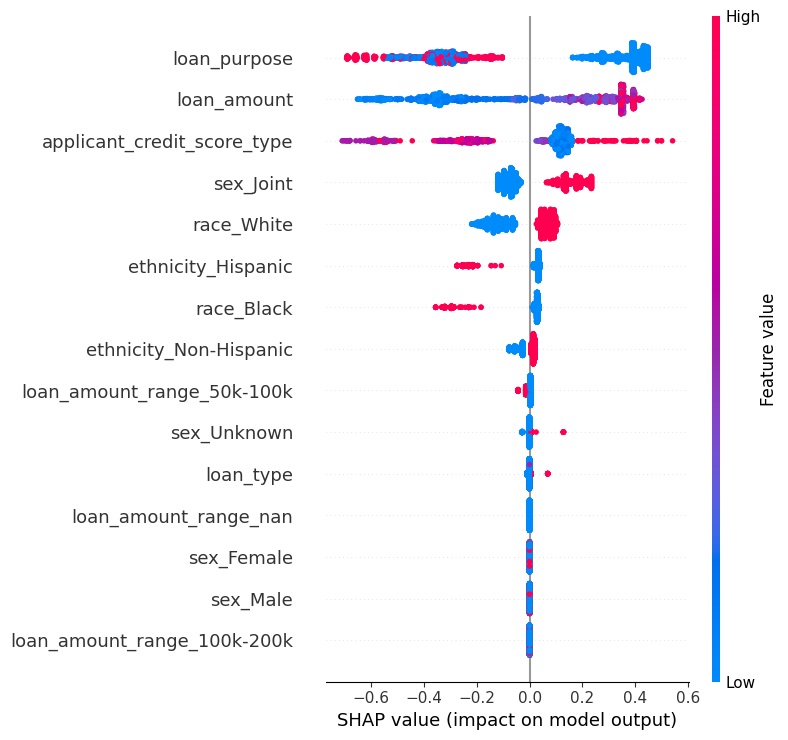

In [108]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Extract pipeline parts
# =========================
preprocessor = gbt_pipeline.named_steps['preprocessor']
model = gbt_pipeline.named_steps['classifier']

# =========================
# 2. Sample data (IMPORTANT)
# =========================
X_train_sample = X_train.sample(n=3000, random_state=42)
X_test_sample = X_test.sample(n=2000, random_state=42)

# =========================
# 3. Transform data
# =========================
X_train_transformed = preprocessor.transform(X_train_sample)
X_test_transformed = preprocessor.transform(X_test_sample)

# Convert to array if sparse
X_train_array = X_train_transformed.toarray()
X_test_array = X_test_transformed.toarray()

# =========================
# 4. Get feature names
# =========================
num_features = numeric_features

cat_features = preprocessor.named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_features, cat_features])

# Convert to DataFrame
X_train_df = pd.DataFrame(X_train_array, columns=feature_names)
X_test_df = pd.DataFrame(X_test_array, columns=feature_names)

# =========================
# 5. SHAP Explainer
# =========================
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_df)

# Handle binary classification output
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# =========================
# 6. SHAP Summary Plot
# =========================
shap.summary_plot(shap_values, X_test_df, max_display=15)

The SHAP summary plot provides a global view of feature importance and their impact on model predictions.

The most influential features include loan purpose, loan amount, and applicant credit score type, indicating that financial variables play a primary role in predicting loan approval outcomes.

However, demographic variables such as race, ethnicity, and sex also appear among the top contributing features. Specifically, features such as race_White, race_Black, and ethnicity_Hispanic significantly influence prediction outcomes.

### SHAP Waterfall Plots: Individual Explanations by Race

To understand individual predictions, we will generate SHAP waterfall plots for a 'Black' and a 'White' applicant from the test set. These plots show how each feature pushes the model's output from the base value (average prediction) to the final prediction for that specific instance.

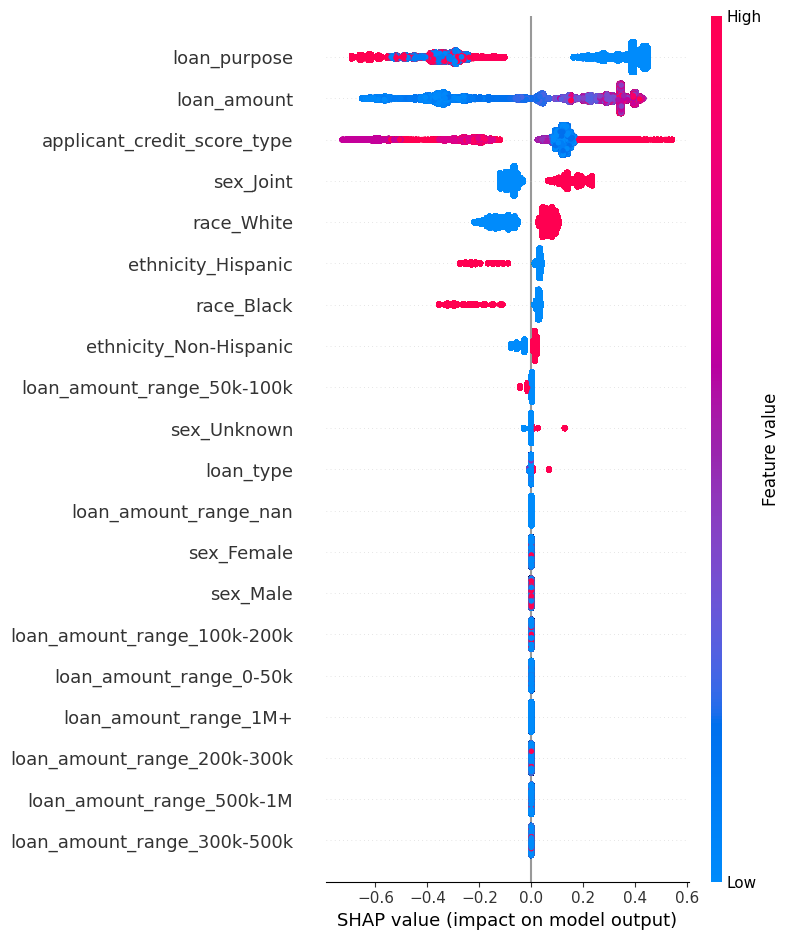

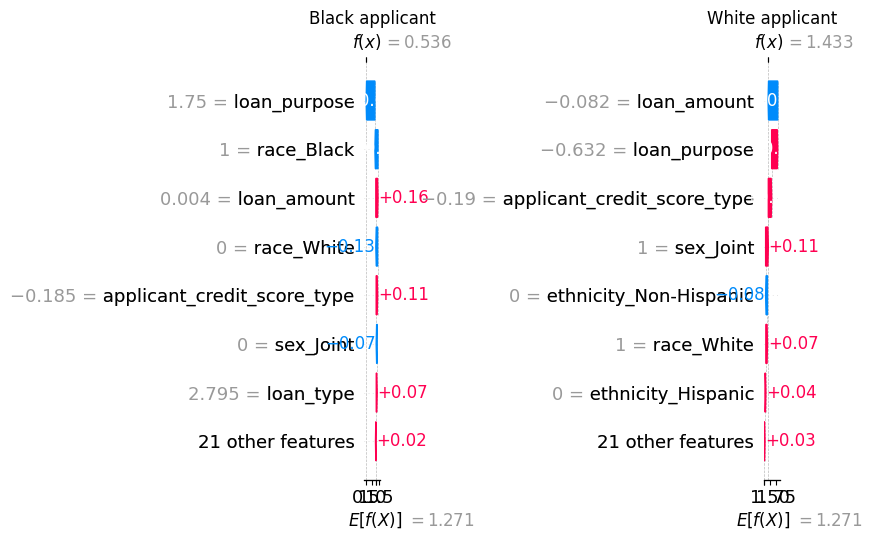

In [111]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Extract pipeline parts
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"]
fitted_classifier = gbt_pipeline.named_steps["classifier"]

# Transform data
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_array = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else X_test_enc

# Feature names
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
)
feat_names = numeric_features + cat_feature_names

# SHAP explainer
explainer_shap = shap.TreeExplainer(fitted_classifier)

shap_values = explainer_shap.shap_values(X_test_enc_array)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# =========================
# Global SHAP plot
# =========================
shap.summary_plot(
    shap_values,
    X_test_enc_array,
    feature_names=feat_names,
    show=False
)
plt.tight_layout()
plt.show()

# =========================
# Select proper samples
# =========================
black_sample = X_test[X_test['race'] == 'Black'].iloc[0]
white_sample = X_test[X_test['race'] == 'White'].iloc[0]

black_loc = X_test.index.get_loc(black_sample.name)
white_loc = X_test.index.get_loc(white_sample.name)

# Base value
expected_value = explainer_shap.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    base_value = expected_value[0] # Corrected from expected_value[1] to expected_value[0]
else:
    base_value = expected_value

# =========================
# Waterfall plots
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, loc, label in [
    (axes[0], black_loc, "Black applicant"),
    (axes[1], white_loc, "White applicant"),
]:
    plt.sca(ax)

    explanation = shap.Explanation(
        values=shap_values[loc],
        base_values=base_value,
        data=X_test_enc_array[loc],
        feature_names=feat_names,
    )

    shap.waterfall_plot(explanation, max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

SHAP waterfall plots were used to analyze how individual features contribute to prediction outcomes for applicants from different racial groups.

For the White applicant, the model predicts a strong approval outcome, driven primarily by loan purpose and credit score type. However, the feature race_White also contributes positively to the prediction, increasing the likelihood of approval.

In contrast, for the Black applicant, the model produces a significantly lower prediction score. While financial features such as loan amount and credit score type contribute positively, the feature race_Black has a substantial negative impact on the prediction.

In [112]:
pip install dice-ml

   â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 2.5/2.5 MB 55.9 MB/s eta 0:00:00


### Counterfactuals with DiCE

In [123]:
import dice_ml
import pandas as pd
import numpy as np

# Assuming gbt_pipeline is your trained Gradient Boosting Tree model pipeline
# and X_train, y_train are your training data.

# Extract the preprocessor and model from the pipeline (These are now used within dice_ml's internal model handling)
# preprocessor = gbt_pipeline.named_steps['preprocessor']
# model = gbt_pipeline.named_steps['classifier']

# The custom predict_proba_gbt function is no longer needed as gbt_pipeline itself has predict_proba
# def predict_proba_gbt(X):
#     X_reordered = X[X_train.columns]
#     X_transformed = preprocessor.transform(X_reordered)
#     return model.predict_proba(X_transformed)

# Create a combined DataFrame for DiCE, including features and the outcome
dice_df = X_train.copy()
dice_df[target_variable] = y_train.copy()

# Create a DiCE data object. The dataframe now includes the target variable.
d = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=numeric_features,
    outcome_name=target_variable
)

# Create a DiCE model object, passing the entire gbt_pipeline which has predict_proba
m = dice_ml.Model(model=gbt_pipeline, backend='sklearn')

# Create a DiCE explainer object
exp = dice_ml.Dice(d, m, method='random')

### Generate Counterfactuals for a Black Applicant

In [124]:
# Select a Black applicant from the test set who was denied (action_taken = 0)
black_denied_applicants = X_test[(X_test['race'] == 'Black') & (y_test == 0)]

if not black_denied_applicants.empty:
    # Use the first denied Black applicant as query instance
    query_instance_black = black_denied_applicants.iloc[[0]]
    print(f"Original Black applicant instance:\n{query_instance_black}")

    # Generate counterfactuals to change prediction to 1 (approved)
    cf_black = exp.generate_counterfactuals(
        query_instance_black,
        total_CFs=1,
        desired_class=1,
        features_to_vary=['loan_amount', 'loan_type', 'loan_purpose', 'applicant_credit_score_type'] # Focus on financial features
    )

    print("\nCounterfactual explanation for Black applicant:")
    cf_black.visualize_as_dataframe(show_only_changes=True)
else:
    print("No denied Black applicants found in the test set to generate counterfactuals.")

Original Black applicant instance:
         loan_amount  loan_type  loan_purpose  applicant_credit_score_type  \
6156316       305000          3            32                            2   

            ethnicity   race     sex loan_amount_range  
6156316  Non-Hispanic  Black  Female         300k-500k  


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1/1 [00:01<00:00,  1.09s/it]


Counterfactual explanation for Black applicant:
Query instance (original outcome : 1)


,loan_amount,loan_type,loan_purpose,applicant_credit_score_type,ethnicity,race,sex,loan_amount_range,action_taken
0,305000,3,32,2,Non-Hispanic,Black,Female,300k-500k,1



Diverse Counterfactual set (new outcome: 1)


,loan_amount,loan_type,loan_purpose,applicant_credit_score_type,ethnicity,race,sex,loan_amount_range,action_taken
0,-,-,-,172,-,-,-,-,-


### Generate Counterfactuals for a White Applicant

In [125]:
# Select a White applicant from the test set who was denied (action_taken = 0)
white_denied_applicants = X_test[(X_test['race'] == 'White') & (y_test == 0)]

if not white_denied_applicants.empty:
    # Use the first denied White applicant as query instance
    query_instance_white = white_denied_applicants.iloc[[0]]
    print(f"Original White applicant instance:\n{query_instance_white}")

    # Generate counterfactuals to change prediction to 1 (approved)
    cf_white = exp.generate_counterfactuals(
        query_instance_white,
        total_CFs=1,
        desired_class=1,
        features_to_vary=['loan_amount', 'loan_type', 'loan_purpose', 'applicant_credit_score_type'] # Focus on financial features
    )

    print("\nCounterfactual explanation for White applicant:")
    cf_white.visualize_as_dataframe(show_only_changes=True)
else:
    print("No denied White applicants found in the test set to generate counterfactuals.")

Original White applicant instance:
         loan_amount  loan_type  loan_purpose  applicant_credit_score_type  \
9662502       135000          1             1                            1   

        ethnicity   race    sex loan_amount_range  
9662502   Unknown  White  Joint         100k-200k  


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1/1 [00:01<00:00,  1.09s/it]


Counterfactual explanation for White applicant:
Query instance (original outcome : 1)


,loan_amount,loan_type,loan_purpose,applicant_credit_score_type,ethnicity,race,sex,loan_amount_range,action_taken
0,135000,1,1,1,Unknown,White,Joint,100k-200k,1



Diverse Counterfactual set (new outcome: 1)


,loan_amount,loan_type,loan_purpose,applicant_credit_score_type,ethnicity,race,sex,loan_amount_range,action_taken
0,-,3,-,-,-,-,-,-,-


In [126]:
# ===============================
# 1. Install DiCE (if needed)
# ===============================
# !pip install dice-ml

# ===============================
# 2. Imports
# ===============================
import dice_ml
from dice_ml import Dice
import pandas as pd

# ===============================
# 3. Prepare Data
# ===============================
# Combine features and target
df_dice = X_train.copy()
df_dice['action_taken'] = y_train

# Define continuous features (adjust if needed)
continuous_features = ['loan_amount']

# ===============================
# 4. Create DiCE Data Object
# ===============================
d = dice_ml.Data(
    dataframe=df_dice,
    continuous_features=continuous_features,
    outcome_name='action_taken'
)

# ===============================
# 5. Wrap Your Pipeline Model
# ===============================
m = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn"
)

# ===============================
# 6. Create Explainer
# ===============================
exp = Dice(d, m)

# ===============================
# 7. Select Applicants
# ===============================
black_applicant = X_test[X_test['race'] == 'Black'].iloc[0:1]
white_applicant = X_test[X_test['race'] == 'White'].iloc[0:1]

# ===============================
# 8. Generate Counterfactuals
# ===============================

print("\n  Counterfactuals: Black â†’ White")

cf_black = exp.generate_counterfactuals(
    black_applicant,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=['race']  #
)

cf_black.visualize_as_dataframe()


print("\n Counterfactuals: White â†’ Black")

cf_white = exp.generate_counterfactuals(
    white_applicant,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=['race']
)

cf_white.visualize_as_dataframe()


  Counterfactuals: Black â†’ White


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 1/1 [00:00<00:00, 67.10it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


UserConfigValidationException: No counterfactuals found for any of the query points! Kindly check your configuration.

## Cell A - PSI Drift Monitoring

Splits the test set 50/50 (wave 1 vs wave 2) and computes Population Stability Index (PSI) for loan_amount and loan_type. Threshold conventions: PSI under 0.10 stable, 0.10 to 0.25 monitor, above 0.25 unstable.

In [ ]:
import numpy as np
import pandas as pd

def _psi_one_feature(expected, actual, bins=10, eps=1e-6):
    e = pd.Series(expected).dropna().astype(float).values
    a = pd.Series(actual).dropna().astype(float).values
    if len(e) == 0 or len(a) == 0:
        return float('nan')
    edges = np.unique(np.quantile(e, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    e_pct = np.histogram(e, bins=edges)[0] / len(e)
    a_pct = np.histogram(a, bins=edges)[0] / len(a)
    e_pct = np.clip(e_pct, eps, None)
    a_pct = np.clip(a_pct, eps, None)
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

def _stability_label(v):
    if v < 0.10: return 'Stable'
    if v < 0.25: return 'Monitor'
    return 'Unstable'

rng = np.random.default_rng(42)
order = np.arange(len(X_test))
rng.shuffle(order)
half = len(order) // 2
wave1 = X_test.iloc[order[:half]]
wave2 = X_test.iloc[order[half:]]

psi_rows = []
for col in ['loan_amount', 'loan_type']:
    v = _psi_one_feature(wave1[col], wave2[col])
    psi_rows.append({'feature': col, 'PSI': round(v, 6), 'stability': _stability_label(v)})

psi_df = pd.DataFrame(psi_rows)
print('=== Cell A: PSI drift (test wave 1 vs wave 2) ===')
print(psi_df.to_string(index=False))

## Cell B - Brier Score and Reliability Curve

Computes Brier score for GBT and RF on the held-out test set and saves the GBT reliability curve to figures/reliability_curve.png.

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

os.makedirs('figures', exist_ok=True)

p_gbt = gbt_pipeline.predict_proba(X_test)[:, 1]
p_rf  = rf_pipeline.predict_proba(X_test)[:, 1]

brier_gbt = brier_score_loss(y_test, p_gbt)
brier_rf  = brier_score_loss(y_test, p_rf)

print('=== Cell B: Brier scores ===')
print(f'GBT Brier score: {brier_gbt:.4f}')
print(f'RF  Brier score: {brier_rf:.4f}')

frac_pos, mean_pred = calibration_curve(y_test, p_gbt, n_bins=10, strategy='quantile')
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(mean_pred, frac_pos, marker='o', label=f'GBT (Brier = {brier_gbt:.3f})')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability curve - GBT (HMDA test set)')
plt.legend()
plt.tight_layout()
plt.savefig('figures/reliability_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell C - Mitigation 1: Remove derived_race

Re-fits the GBT pipeline with the mapped race column dropped from the feature set, then recomputes False Negative Rate by race group on the held-out test set. Reports a before/after table with delta.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix
import pandas as pd

features_no_race = [c for c in X_train.columns if c != 'race']
num_no_race = [c for c in features_no_race if c in numeric_features]
cat_no_race = [c for c in features_no_race if c in categorical_features]

pre_no_race = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_no_race),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_no_race),
])
gbt_no_race = Pipeline([
    ('preprocessor', pre_no_race),
    ('classifier', GradientBoostingClassifier(n_estimators=20, max_depth=2, random_state=42)),
])
gbt_no_race.fit(X_train[features_no_race], y_train)

y_pred_with_race = gbt_pipeline.predict(X_test)
y_pred_no_race   = gbt_no_race.predict(X_test[features_no_race])

def _fnr_by_race(y_true, y_pred, race_series):
    rows = []
    for r in sorted(race_series.astype(str).unique()):
        mask = (race_series.astype(str) == r).values
        if mask.sum() == 0:
            continue
        cm = confusion_matrix(y_true[mask], y_pred[mask], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')
        rows.append({'race': r, 'n': int(mask.sum()), 'FNR': round(fnr, 4)})
    return pd.DataFrame(rows).set_index('race')

fnr_with    = _fnr_by_race(y_test, y_pred_with_race, X_test['race'])
fnr_without = _fnr_by_race(y_test, y_pred_no_race,   X_test['race'])

mitig_table = pd.DataFrame({
    'n': fnr_with['n'],
    'FNR (with race)': fnr_with['FNR'],
    'FNR (no race)': fnr_without['FNR'],
})
mitig_table['delta'] = (mitig_table['FNR (no race)'] - mitig_table['FNR (with race)']).round(4)

print('=== Cell C: Mitigation 1 - remove derived_race ===')
print(mitig_table.to_string())

## Cell D - Mitigation 2: Slice Threshold Adjustment

For race groups that fail the 4/5 rule under the baseline 0.50 cutoff (Multiracial, Pacific Islander), lower the approval threshold to 0.45 and recompute Adverse Impact Ratio (AIR) and FPR against the White reference group.

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

p_gbt = gbt_pipeline.predict_proba(X_test)[:, 1]

ref_group = 'White'
ref_mask = (X_test['race'].astype(str) == ref_group).values
ref_sel_50 = (p_gbt[ref_mask] >= 0.50).mean()

target_groups = ['Multiracial', 'Pacific Islander']
all_groups = target_groups + [ref_group]

rows = []
for g in all_groups:
    mask = (X_test['race'].astype(str) == g).values
    if mask.sum() == 0:
        continue

    pred_old = (p_gbt[mask] >= 0.50).astype(int)
    sel_old = pred_old.mean()
    air_old = sel_old / ref_sel_50 if ref_sel_50 > 0 else float('nan')
    cm_old = confusion_matrix(y_test[mask], pred_old, labels=[0, 1])
    tn, fp, fn, tp = cm_old.ravel()
    fpr_old = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

    thr = 0.45 if g in target_groups else 0.50
    pred_new = (p_gbt[mask] >= thr).astype(int)
    sel_new = pred_new.mean()
    air_new = sel_new / ref_sel_50 if ref_sel_50 > 0 else float('nan')
    cm_new = confusion_matrix(y_test[mask], pred_new, labels=[0, 1])
    tn, fp, fn, tp = cm_new.ravel()
    fpr_new = fp / (fp + tn) if (fp + tn) > 0 else float('nan')

    rows.append({
        'group': g, 'n': int(mask.sum()), 'threshold': thr,
        'old AIR': round(air_old, 3), 'new AIR': round(air_new, 3),
        'old FPR': round(fpr_old, 3), 'new FPR': round(fpr_new, 3),
    })

print('=== Cell D: Mitigation 2 - slice threshold adjustment ===')
print(pd.DataFrame(rows).to_string(index=False))